# Architecture A — single-agent baseline

Questa notebook prepara l'ambiente su Colab, clona la repo, configura i modelli HuggingFace e lancia il grafo per l'architettura **A** (single-agent → tester). Salva i log in `log/`.

Note operative:
- Imposta un token HuggingFace valido (HF Inference API) quando richiesto.
- Lancia pochi task della APPS per evitare costi/tempo eccessivi.
- I log sono salvati sia su stdout sia in file JSONL/LOG per analisi successive.

In [1]:
import os
import sys
import subprocess
import pathlib

REPO_URL = "https://github.com/LLM4SE-group-15/ArchitecturesForCodeDevelopmentWithLLMs.git"
REPO_DIR = pathlib.Path("/content/ArchitecturesForCodeDevelopmentWithLLMs")

if not REPO_DIR.exists():
    subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

os.chdir(REPO_DIR)
subprocess.run([sys.executable, "-m", "pip", "install", "-U", "pip"], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"], check=True)

print(f"Using repo at {REPO_DIR.resolve()}")

Cloning into '/content/ArchitecturesForCodeDevelopmentWithLLMs'...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.5 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastai 2.8.4 requires fastcore<1.9,>=1.8.0, but you have fastcore 1.11.3 which is incompatible.


INFO: pip is looking at multiple versions of langchain-huggingface to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of langgraph-prebuilt to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of langgraph-prebuilt to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 9.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.4/536.4 kB

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.22.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-colab 1.0.0 requires google-auth==2.38.0, but you have google-auth 2.47.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
cudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
gradio 5.49.1 requires pydantic<2.12,>=2.0, but you have pydantic 2.12.5 which is incompatible.
bigframes 2.26.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
fastai

In [2]:
!pip install -r requirements.txt

In [ ]:
import os
import getpass
from huggingface_hub import login

# Configurazione LangSmith
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "project_name"
os.environ["LANGCHAIN_API_KEY"] = "langchain_api_key"

# Forza sempre l'uso del token che inserisci
os.environ["HF_TOKEN"] = "hf_token"
login(token=os.environ["HF_TOKEN"], add_to_git_credential=False)

os.environ["ARCHITECTURE"] = "A"
print("ARCHITECTURE set to", os.environ["ARCHITECTURE"])

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


ARCHITECTURE set to A


In [4]:
from huggingface_hub import HfApi

api = HfApi()
try:
    user_info = api.whoami(token=os.environ["HF_TOKEN"])
    print("Logged in to Hugging Face as:", user_info.get("name") or user_info.get("user"))
except Exception as exc:
    print("Login check failed:", exc)

Logged in to Hugging Face as: Riaburger


In [5]:
import json
import time
import logging
import pathlib
import os

from datetime import datetime

DEFAULT_ROOT = pathlib.Path("/content/ArchitecturesForCodeDevelopmentWithLLMs")
ROOT = DEFAULT_ROOT if DEFAULT_ROOT.exists() else pathlib.Path.cwd()

sys.path.insert(0, str(ROOT))

LOG_DIR = ROOT / "log"
LOG_DIR.mkdir(exist_ok=True)

logger = logging.getLogger("architecture_A")
logger.setLevel(logging.INFO)
if logger.handlers:
    logger.handlers.clear()
formatter = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
file_handler = logging.FileHandler(LOG_DIR / "architecture_A.log")
stream_handler = logging.StreamHandler()
for handler in (file_handler, stream_handler):
    handler.setFormatter(formatter)
    logger.addHandler(handler)

logger.info("Logger ready. Repo root: %s", ROOT)
logger.info("Log files: %s", LOG_DIR)
print("Logs ->", LOG_DIR)

2026-01-28 13:07:14,500 | INFO | Logger ready. Repo root: /content/ArchitecturesForCodeDevelopmentWithLLMs
2026-01-28 13:07:14,500 | INFO | Log files: /content/ArchitecturesForCodeDevelopmentWithLLMs/log


Logs -> /content/ArchitecturesForCodeDevelopmentWithLLMs/log


In [6]:
import time
import json
import random
from src.data.task_loader import HumanEvalTaskLoader
from src.graph.graph import run_graph
from src.agents.llm import Architecture

ARCH = Architecture.A
SEED_FIXED = 31

def run_humaneval_benchmark(limit: int = 15, shuffle: bool = True):
    """
    Run benchmark on HumanEval tasks.
    
    Args:
        limit: Number of tasks to run
        shuffle: If True, randomly sample tasks with fixed seed
    """
    loader = HumanEvalTaskLoader()
    all_tasks = loader.load_all()  # Carica tutti i 164 task
    
    if shuffle:
        random.seed(SEED_FIXED)
        tasks = random.sample(all_tasks, min(limit, len(all_tasks)))
    else:
        tasks = all_tasks[:limit]

    results = []
    total = len(tasks)
    logger.info("Loaded %s tasks from HumanEval (shuffle=%s, seed=%s)", total, shuffle, SEED_FIXED)
    print(f"Starting benchmark on {total} tasks...")
    
    for idx, task in enumerate(tasks, 1):
        logger.info("Running %s/%s %s", idx, total, task.task_id)
        print(f"[{idx}/{total}] Task {task.task_id} ({task.entry_point})... ", end="", flush=True)
        
        start = time.time()
        
        state = run_graph(
            task_id=task.task_id,
            task_description=task.prompt,
            test_code=task.test,
            entry_point=task.entry_point,
            architecture=ARCH,
        )

        elapsed = time.time() - start
        
        record = {
            "task_id": task.task_id,
            "entry_point": task.entry_point,
            "architecture": str(ARCH.value),
            "test_passed": state["test_passed"],
            "developer_tier": state.get("developer_tier"),
            "escalations": state["escalations"],
            "story_points_initial": state.get("story_points_initial"),
            "story_points_final": state.get("story_points_current"),
            "elapsed_seconds": elapsed,
            "generated_code": state.get("generated_code", ""),
        }
        results.append(record)
        
        logger.info(
            "Finished %s | pass=%s tier=%s escalations=%s elapsed=%.1fs",
            task.task_id,
            state["test_passed"],
            record["developer_tier"],
            record["escalations"],
            elapsed,
        )
        status_str = "PASS" if state["test_passed"] else "FAIL"
        print(f"{status_str} in {elapsed:.1f}s")

        with open(LOG_DIR / "architecture_A.jsonl", "a", encoding="utf-8") as f:
            f.write(json.dumps(record) + "\n")
            
    return results

# Esecuzione: 15 task random (seed=31 per riproducibilita)
sample_results = run_humaneval_benchmark(limit=164, shuffle=False)

# Sommario
passed_count = sum(1 for r in sample_results if r['test_passed'])
print(f"\nBenchmark Completed. Passed: {passed_count}/{len(sample_results)}")

Loading HumanEval dataset...


Generating test split:   0%|          | 0/164 [00:00<?, ? examples/s]

2026-01-28 13:07:19,343 | INFO | Loaded 164 tasks from HumanEval (shuffle=False, seed=31)
2026-01-28 13:07:19,344 | INFO | Running 1/164 HumanEval/0


Loaded 164 tasks.
Starting benchmark on 164 tasks...
[1/164] Task HumanEval/0 (has_close_elements)... 

2026-01-28 13:07:22,091 | INFO | Finished HumanEval/0 | pass=True tier=None escalations=0 elapsed=2.7s
2026-01-28 13:07:22,092 | INFO | Running 2/164 HumanEval/1


...

PASS in 2.6s
[163/164] Task HumanEval/162 (string_to_md5)... 

2026-01-28 13:15:23,913 | INFO | Finished HumanEval/162 | pass=True tier=None escalations=0 elapsed=1.7s
2026-01-28 13:15:23,914 | INFO | Running 164/164 HumanEval/163


PASS in 1.7s
[164/164] Task HumanEval/163 (generate_integers)... 

2026-01-28 13:15:28,399 | INFO | Finished HumanEval/163 | pass=False tier=None escalations=0 elapsed=4.5s


FAIL in 4.5s

Benchmark Completed. Passed: 111/164


In [7]:
!cd log && cat architecture_A.jsonl

{"task_id": "HumanEval/0", "entry_point": "has_close_elements", "architecture": "A", "test_passed": true, "developer_tier": null, "escalations": 0, "story_points_initial": null, "story_points_final": null, "elapsed_seconds": 2.7457358837127686, "generated_code": "from typing import List\n\ndef has_close_elements(numbers: List[float], threshold: float) -> bool:\n    \"\"\" Check if in given list of numbers, are any two numbers closer to each other than given threshold. \"\"\"\n    sorted_numbers = sorted(numbers)\n    for i in range(len(sorted_numbers) - 1):\n        if abs(sorted_numbers[i] - sorted_numbers[i + 1]) < threshold:\n            return True\n    return False"}
{"task_id": "HumanEval/1", "entry_point": "separate_paren_groups", "architecture": "A", "test_passed": true, "developer_tier": null, "escalations": 0, "story_points_initial": null, "story_points_final": null, "elapsed_seconds": 4.283915281295776, "generated_code": "from typing import List\n\ndef separate_paren_groups(

## Evaluation Metrics for Architecture A

This section calculates the evaluation metrics as specified in `evaluation.md`:

- **Primary Metrics**: Pass Rate, Pass@1
- **Cost Metrics**: Execution Time, API Calls
- **Pass Rate**

In [8]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load results from JSONL file
log_file = LOG_DIR / "architecture_A.jsonl"
results = []
if log_file.exists():
    with open(log_file, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                results.append(json.loads(line))
else:
    print(f"Warning: {log_file} not found. Make sure to run the tasks first.")

df = pd.DataFrame(results)
print(f"Loaded {len(df)} task results")

# Mostra tutte le righe
pd.set_option('display.max_rows', None)
df

Loaded 164 task results


,task_id,entry_point,architecture,test_passed,developer_tier,escalations,story_points_initial,story_points_final,elapsed_seconds,generated_code
0,HumanEval/0,has_close_elements,A,True,None,0,None,None,2.745736,from typing import List\n\ndef has_close_eleme...
1,HumanEval/1,separate_paren_groups,A,True,None,0,None,None,4.283915,from typing import List\n\ndef separate_paren_...
2,HumanEval/2,truncate_number,A,False,None,0,None,None,2.618217,"json\n{\n ""generated_code"": ""def truncate_num..."
3,HumanEval/3,below_zero,A,False,None,0,None,None,2.474592,"json\n{\n ""generated_code"": ""from typing impo..."
4,HumanEval/4,mean_absolute_deviation,A,True,None,0,None,None,1.945944,from typing import List\n\ndef mean_absolute_d...
5,HumanEval/5,intersperse,A,False,None,0,None,None,4.014062,"json\n{\n ""generated_code"": ""from typing impo..."
6,HumanEval/6,parse_nested_parens,A,True,None,0,None,None,3.710247,from typing import List\n\ndef parse_nested_pa...
7,HumanEval/7,filter_by_substring,A,False,None,0,None,None,2.807277,"json\n{\n ""generated_code"": ""from typing impo..."
8,HumanEval/8,sum_product,A,False,None,0,None,None,3.233824,"json\n{\n ""generated_code"": ""from typing impo..."
9,HumanEval/9,rolling_max,A,True,None,0,None,None,2.000154,from typing import List\n\ndef rolling_max(num...


In [9]:
# Static Code Quality Metrics (Radon)
# Calculates Cyclomatic Complexity and Maintainability Index for generated code

from radon.complexity import cc_visit
from radon.metrics import mi_visit

def calculate_static_metrics(code: str) -> dict:
    """Calculate static code quality metrics using Radon."""
    if not code or not code.strip():
        return {
            "cyclomatic_complexity_avg": None, 
            "cyclomatic_complexity_max": None,
            "maintainability_index": None
        }
    
    try:
        # Cyclomatic Complexity - average across all functions
        cc_results = cc_visit(code)
        if cc_results:
            avg_cc = sum(block.complexity for block in cc_results) / len(cc_results)
            max_cc = max(block.complexity for block in cc_results)
        else:
            avg_cc = 1  # No functions = simple code
            max_cc = 1
    except Exception:
        avg_cc = None
        max_cc = None
    
    try:
        # Maintainability Index (0-100, higher is better)
        mi_score = mi_visit(code, multi=False)
    except Exception:
        mi_score = None
    
    return {
        "cyclomatic_complexity_avg": avg_cc,
        "cyclomatic_complexity_max": max_cc,
        "maintainability_index": mi_score
    }

# Calculate metrics for all generated code
print("\nCalculating static code quality metrics...")
static_metrics = []
for idx, row in df.iterrows():
    code = row.get("generated_code", "")
    metrics = calculate_static_metrics(code)
    metrics["task_id"] = row["task_id"]
    metrics["test_passed"] = row["test_passed"]
    static_metrics.append(metrics)

metrics_df = pd.DataFrame(static_metrics)

# Add to main dataframe
df["cyclomatic_complexity_avg"] = metrics_df["cyclomatic_complexity_avg"]
df["cyclomatic_complexity_max"] = metrics_df["cyclomatic_complexity_max"]
df["maintainability_index"] = metrics_df["maintainability_index"]

# Summary statistics
valid_cc = metrics_df["cyclomatic_complexity_avg"].dropna()
valid_mi = metrics_df["maintainability_index"].dropna()

print("\n" + "=" * 60)
print("STATIC CODE QUALITY METRICS")
print("=" * 60)
print(f"\nCyclomatic Complexity (lower is better):")
print(f"  Average CC: {valid_cc.mean():.2f}" if len(valid_cc) > 0 else "  Average CC: N/A")
print(f"  Median CC: {valid_cc.median():.2f}" if len(valid_cc) > 0 else "  Median CC: N/A")
print(f"  Max CC: {metrics_df['cyclomatic_complexity_max'].max():.2f}" if metrics_df['cyclomatic_complexity_max'].notna().any() else "  Max CC: N/A")
print(f"\nMaintainability Index (0-100, higher is better):")
print(f"  Average MI: {valid_mi.mean():.2f}" if len(valid_mi) > 0 else "  Average MI: N/A")
print(f"  Median MI: {valid_mi.median():.2f}" if len(valid_mi) > 0 else "  Median MI: N/A")
print(f"  Min MI: {valid_mi.min():.2f}" if len(valid_mi) > 0 else "  Min MI: N/A")
print("=" * 60)

# Passed vs Failed comparison
passed_df = metrics_df[metrics_df["test_passed"] == True]
failed_df = metrics_df[metrics_df["test_passed"] == False]

print(f"\nComparison - Passed vs Failed Tasks:")
print(f"  Passed tasks - Avg CC: {passed_df['cyclomatic_complexity_avg'].mean():.2f}, Avg MI: {passed_df['maintainability_index'].mean():.2f}" if len(passed_df) > 0 else "  Passed tasks: No data")
print(f"  Failed tasks - Avg CC: {failed_df['cyclomatic_complexity_avg'].mean():.2f}, Avg MI: {failed_df['maintainability_index'].mean():.2f}" if len(failed_df) > 0 else "  Failed tasks: No data")



Calculating static code quality metrics...

STATIC CODE QUALITY METRICS

Cyclomatic Complexity (lower is better):
  Average CC: 3.59
  Median CC: 3.00
  Max CC: 14.00

Maintainability Index (0-100, higher is better):
  Average MI: 75.02
  Median MI: 71.56
  Min MI: 50.24

Comparison - Passed vs Failed Tasks:
  Passed tasks - Avg CC: 3.67, Avg MI: 74.84
  Failed tasks - Avg CC: 3.21, Avg MI: 75.86


In [10]:
# Helper function for Wilson score confidence interval
def wilson_ci(successes, n, confidence=0.95):
    """Calculate Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0, 0, 0
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    p_hat = successes / n
    denominator = 1 + z**2 / n
    center = (p_hat + z**2 / (2 * n)) / denominator
    margin = z * np.sqrt((p_hat * (1 - p_hat) + z**2 / (4 * n)) / n) / denominator
    return p_hat, center - margin, center + margin

# Calculate Pass Rate
total_tasks = len(df)
passed_tasks = df["test_passed"].sum()
pass_rate = passed_tasks / total_tasks if total_tasks > 0 else 0

# For Architecture A, Pass@1 is the same as Pass Rate (no retries)
pass_at_1 = pass_rate

# Calculate 95% Confidence Interval
p, ci_low, ci_high = wilson_ci(passed_tasks, total_tasks)

print("=" * 60)
print("PRIMARY METRICS - Architecture A (Single-Agent Baseline)")
print("=" * 60)
print(f"\nDataset: HumanEval (164 total problems)")
print(f"Tasks Evaluated: {total_tasks}")
print(f"Tasks Passed: {passed_tasks}")
print(f"Pass Rate: {pass_rate:.2%}")
print(f"Pass@1: {pass_at_1:.2%}")
print(f"95% Confidence Interval: [{ci_low:.2%}, {ci_high:.2%}]")
print("=" * 60)

PRIMARY METRICS - Architecture A (Single-Agent Baseline)

Dataset: HumanEval (164 total problems)
Tasks Evaluated: 164
Tasks Passed: 111
Pass Rate: 67.68%
Pass@1: 67.68%
95% Confidence Interval: [60.19%, 74.37%]


In [11]:
# Calculate Cost Metrics
avg_time = df["elapsed_seconds"].mean()
std_time = df["elapsed_seconds"].std()
median_time = df["elapsed_seconds"].median()
total_time = df["elapsed_seconds"].sum()
min_time = df["elapsed_seconds"].min()
max_time = df["elapsed_seconds"].max()

# For Architecture A, each task is 1 API call (single-agent, no retry)
api_calls_per_task = 1
total_api_calls = total_tasks * api_calls_per_task

print("\n" + "=" * 60)
print("COST METRICS")
print("=" * 60)
print(f"\nExecution Time Statistics:")
print(f"  Average Time per Task: {avg_time:.2f} seconds")
print(f"  Std Dev: {std_time:.2f} seconds")
print(f"  Median Time: {median_time:.2f} seconds")
print(f"  Min Time: {min_time:.2f} seconds")
print(f"  Max Time: {max_time:.2f} seconds")
print(f"  Total Execution Time: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")
print(f"\nAPI Calls:")
print(f"  API Calls per Task: {api_calls_per_task}")
print(f"  Total API Calls: {total_api_calls}")
print("=" * 60)


COST METRICS

Execution Time Statistics:
  Average Time per Task: 2.98 seconds
  Std Dev: 1.02 seconds
  Median Time: 2.76 seconds
  Min Time: 1.51 seconds
  Max Time: 7.16 seconds
  Total Execution Time: 488.66 seconds (8.14 minutes)

API Calls:
  API Calls per Task: 1
  Total API Calls: 164


In [12]:
# Show per-task results
print("\n" + "=" * 60)
print("PER-TASK RESULTS")
print("=" * 60)
print("\n| Task ID           | Entry Point                  | Passed | Time (s) |")
print("|-------------------|------------------------------|--------|----------|")
for _, row in df.iterrows():
    status = "PASS" if row["test_passed"] else "FAIL"
    print(f"| {row['task_id']:<17} | {row['entry_point']:<28} | {status:<6} | {row['elapsed_seconds']:>8.2f} |")
print("=" * 60)


PER-TASK RESULTS

| Task ID           | Entry Point                  | Passed | Time (s) |
|-------------------|------------------------------|--------|----------|
| HumanEval/0       | has_close_elements           | PASS   |     2.75 |
| HumanEval/1       | separate_paren_groups        | PASS   |     4.28 |
| HumanEval/2       | truncate_number              | FAIL   |     2.62 |
| HumanEval/3       | below_zero                   | FAIL   |     2.47 |
| HumanEval/4       | mean_absolute_deviation      | PASS   |     1.95 |
| HumanEval/5       | intersperse                  | FAIL   |     4.01 |
| HumanEval/6       | parse_nested_parens          | PASS   |     3.71 |
| HumanEval/7       | filter_by_substring          | FAIL   |     2.81 |
| HumanEval/8       | sum_product                  | FAIL   |     3.23 |
| HumanEval/9       | rolling_max                  | PASS   |     2.00 |
| HumanEval/10      | make_palindrome              | FAIL   |     2.81 |
| HumanEval/11      | string_xor

In [13]:
# For Architecture A, there are no retries (single-shot)
print("\n" + "=" * 60)
print("RETRY DYNAMICS")
print("=" * 60)
print("\nNote: Architecture A is a single-shot baseline with no retry mechanism.")
print("\n| Retries | Count | Percentage |")
print("|---------|-------|------------|")
print(f"| 0       | {total_tasks:>5} | {100:>10.2f}% |")
print("=" * 60)


RETRY DYNAMICS

Note: Architecture A is a single-shot baseline with no retry mechanism.

| Retries | Count | Percentage |
|---------|-------|------------|
| 0       |   164 |     100.00% |


/tmp/ipykernel_24/2622949188.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(box_data, labels=["Passed", "Failed"], patch_artist=True)


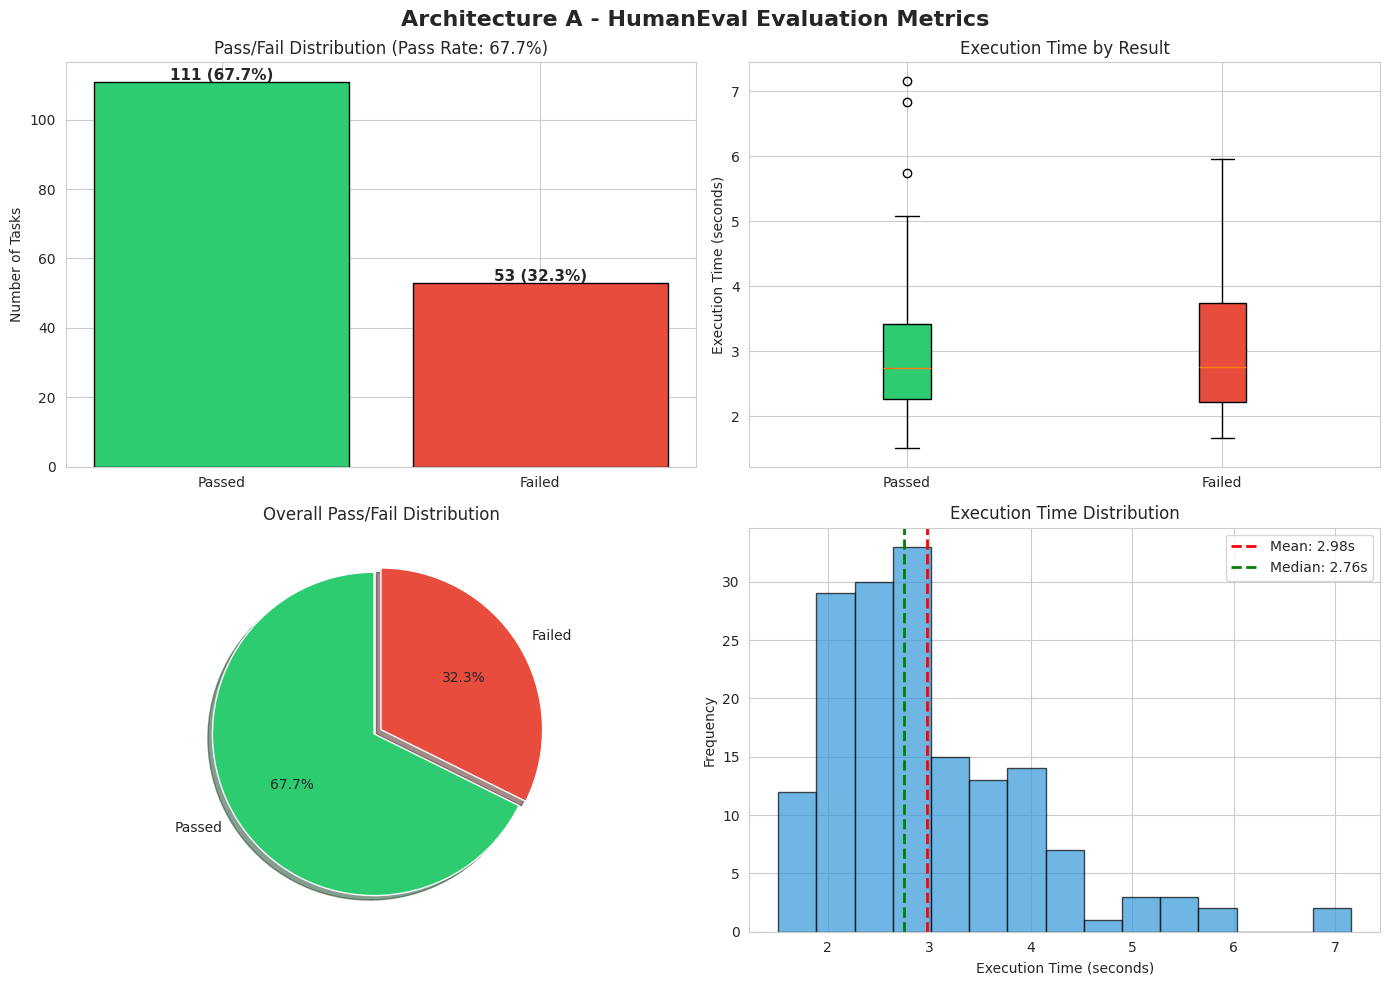


Visualization saved to: /content/ArchitecturesForCodeDevelopmentWithLLMs/log/architecture_A_metrics.png


In [14]:
# Visualizations
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 10)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Architecture A - HumanEval Evaluation Metrics", fontsize=16, fontweight="bold")

# 1. Pass/Fail Bar Chart
ax1 = axes[0, 0]
categories = ["Passed", "Failed"]
counts = [passed_tasks, total_tasks - passed_tasks]
colors = ["#2ecc71", "#e74c3c"]
bars = ax1.bar(categories, counts, color=colors, edgecolor="black")
ax1.set_ylabel("Number of Tasks")
ax1.set_title(f"Pass/Fail Distribution (Pass Rate: {pass_rate:.1%})")
for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f"{count} ({count/total_tasks:.1%})", ha="center", fontsize=11, fontweight="bold")

# 2. Execution Time Box Plot
ax2 = axes[0, 1]
passed_times = df[df["test_passed"]]["elapsed_seconds"]
failed_times = df[~df["test_passed"]]["elapsed_seconds"]
box_data = [passed_times, failed_times]
bp = ax2.boxplot(box_data, labels=["Passed", "Failed"], patch_artist=True)
bp["boxes"][0].set_facecolor("#2ecc71")
bp["boxes"][1].set_facecolor("#e74c3c")
ax2.set_ylabel("Execution Time (seconds)")
ax2.set_title("Execution Time by Result")

# 3. Pass/Fail Pie Chart
ax3 = axes[1, 0]
labels = ["Passed", "Failed"]
sizes = [passed_tasks, total_tasks - passed_tasks]
colors_pie = ["#2ecc71", "#e74c3c"]
explode = (0.05, 0)
wedges, texts, autotexts = ax3.pie(sizes, explode=explode, labels=labels, colors=colors_pie, 
                                   autopct="%1.1f%%", shadow=True, startangle=90)
ax3.set_title("Overall Pass/Fail Distribution")

# 4. Execution Time Histogram
ax4 = axes[1, 1]
ax4.hist(df["elapsed_seconds"], bins=15, edgecolor="black", color="#3498db", alpha=0.7)
ax4.axvline(avg_time, color="red", linestyle="--", linewidth=2, label=f"Mean: {avg_time:.2f}s")
ax4.axvline(median_time, color="green", linestyle="--", linewidth=2, label=f"Median: {median_time:.2f}s")
ax4.set_xlabel("Execution Time (seconds)")
ax4.set_ylabel("Frequency")
ax4.set_title("Execution Time Distribution")
ax4.legend()

plt.tight_layout()
plt.savefig(LOG_DIR / "architecture_A_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nVisualization saved to: {LOG_DIR / 'architecture_A_metrics.png'}")

In [15]:
# Summary Table
summary_data = {
    "Metric": [
        "Architecture",
        "Dataset",
        "Total Tasks",
        "Passed Tasks",
        "Pass Rate",
        "Pass@1",
        "95% CI (Lower)",
        "95% CI (Upper)",
        "Avg Execution Time (s)",
        "Std Execution Time (s)",
        "Median Execution Time (s)",
        "Min Execution Time (s)",
        "Max Execution Time (s)",
        "Total Execution Time (s)",
        "API Calls per Task",
        "Total API Calls",
        "Retry Count",
        "Escalations"
    ],
    "Value": [
        "A (Single-Agent Baseline)",
        "HumanEval",
        total_tasks,
        int(passed_tasks),
        f"{pass_rate:.4f}",
        f"{pass_at_1:.4f}",
        f"{ci_low:.4f}",
        f"{ci_high:.4f}",
        f"{avg_time:.2f}",
        f"{std_time:.2f}",
        f"{median_time:.2f}",
        f"{min_time:.2f}",
        f"{max_time:.2f}",
        f"{total_time:.2f}",
        api_calls_per_task,
        total_api_calls,
        0,
        0
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "=" * 60)
print("SUMMARY TABLE FOR ARCHITECTURE A")
print("=" * 60)
print(summary_df.to_string(index=False))

# Save summary
summary_df.to_csv(LOG_DIR / "architecture_A_summary.csv", index=False)

# Save detailed results
df.to_csv(LOG_DIR / "architecture_A_detailed.csv", index=False)

print(f"\nAll results saved to {LOG_DIR}")


SUMMARY TABLE FOR ARCHITECTURE A
                   Metric                     Value
             Architecture A (Single-Agent Baseline)
                  Dataset                 HumanEval
              Total Tasks                       164
             Passed Tasks                       111
                Pass Rate                    0.6768
                   Pass@1                    0.6768
           95% CI (Lower)                    0.6019
           95% CI (Upper)                    0.7437
   Avg Execution Time (s)                      2.98
   Std Execution Time (s)                      1.02
Median Execution Time (s)                      2.76
   Min Execution Time (s)                      1.51
   Max Execution Time (s)                      7.16
 Total Execution Time (s)                    488.66
       API Calls per Task                         1
          Total API Calls                       164
              Retry Count                         0
              Escalations     